In [23]:
from google.colab import drive
drive.mount('/content/drive')

!pip install openpyxl rapidfuzz

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.4 MB/s eta 0:00:00


In [15]:
# load dataset
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('/content/drive/MyDrive/Drugs_dataset/MID.xlsx')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (192807, 20)
Columns: ['NAME', 'LINK', 'CONTAINS', 'INTRODUCTION', 'USES', 'BENEFITS', 'SIDE_EFFECT', 'HOW_TO_USE', 'HOW_WORKS', 'QUICK_TIPS', 'CHEMICAL_CLASS', 'HABIT_FORMING', 'THERAPEUTIC_CLASS', 'ACTION_CLASS', 'SAFETY_ADVICE_TO_ALCOHOL', 'SAFETY_ADVICE_TO_PREGNANCY', 'SAFETY_ADVICE_TO_BREAST_FEEDING', 'SAFETY_ADVICE_TO_DRIVING', 'SAFETY_ADVICE_TO_KIDNEY', 'SAFETY_ADVICE_TO_LIVER']


In [16]:
# basic info and null checks
print("=== Dataset Info ===")
print(f"Total drugs     : {len(df)}")
print(f"Unique drugs    : {df['NAME'].nunique()}")
print(f"Total columns   : {len(df.columns)}")


=== Dataset Info ===
Total drugs     : 192807
Unique drugs    : 147872
Total columns   : 20


In [17]:
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


=== Missing Values ===
                                 Missing Count  Missing %
INTRODUCTION                             11986       6.22
HOW_TO_USE                                  95       0.05
HOW_WORKS                                  236       0.12
QUICK_TIPS                                1463       0.76
CHEMICAL_CLASS                           91334      47.37
ACTION_CLASS                            107072      55.53
SAFETY_ADVICE_TO_ALCOHOL                  9669       5.01
SAFETY_ADVICE_TO_PREGNANCY                9673       5.02
SAFETY_ADVICE_TO_BREAST_FEEDING           9673       5.02
SAFETY_ADVICE_TO_DRIVING                 20533      10.65
SAFETY_ADVICE_TO_KIDNEY                  14446       7.49
SAFETY_ADVICE_TO_LIVER                   14448       7.49


In [24]:
import os
os.makedirs('/content/drive/MyDrive/DrugInteraction_Project/', exist_ok=True)
print("Folder ready:", os.path.exists('/content/drive/MyDrive/DrugInteraction_Project/'))

Folder ready: True


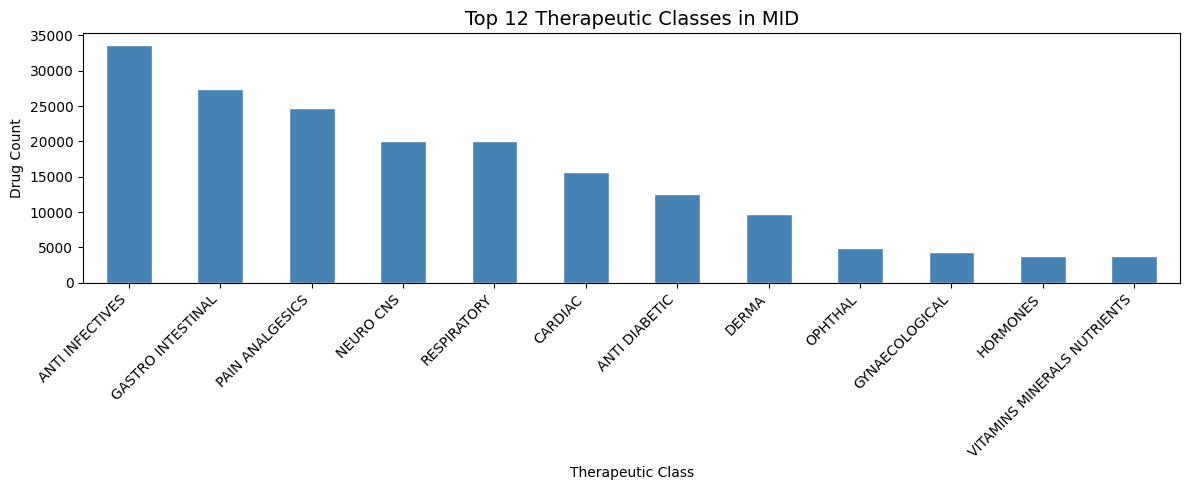

In [31]:
# therapeutic class distribution
import matplotlib.pyplot as plt

top_classes = df['THERAPEUTIC_CLASS'].value_counts().head(12)

plt.figure(figsize=(12, 5))
top_classes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 12 Therapeutic Classes in MID', fontsize=14)
plt.xlabel('Therapeutic Class')
plt.ylabel('Drug Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/eda_therapeutic_class.png')
plt.show()



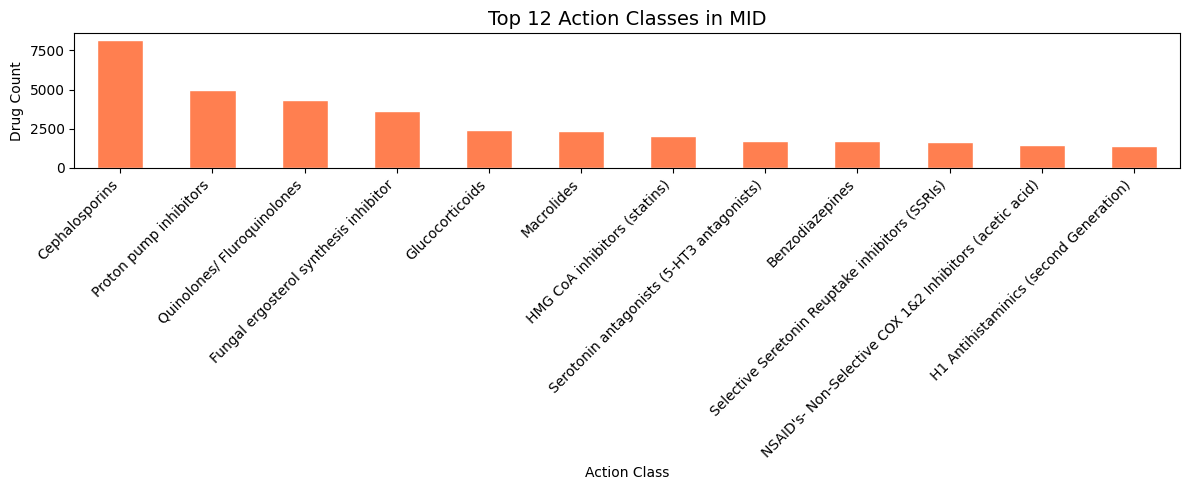

In [32]:
# action class distribution
top_actions = df['ACTION_CLASS'].value_counts().head(12)

plt.figure(figsize=(12, 5))
top_actions.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 12 Action Classes in MID', fontsize=14)
plt.xlabel('Action Class')
plt.ylabel('Drug Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/action_class.png')
plt.show()

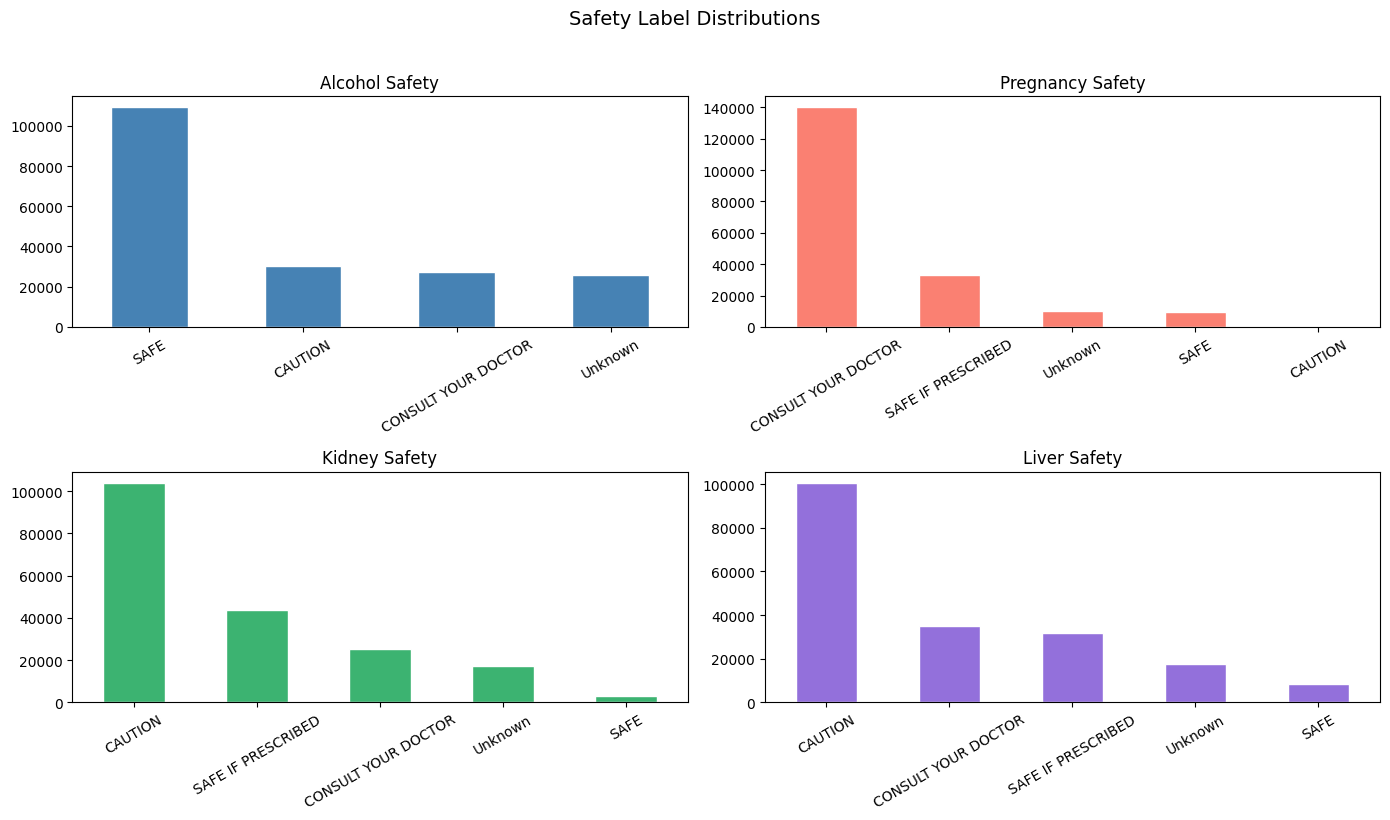

In [33]:
# safety labels analysis
import re

def extract_label(text):
    if pd.isna(text): return 'Unknown'
    match = re.search(r'label:\s*([^,]+)', str(text))
    return match.group(1).strip() if match else 'Unknown'

df['alcohol_label']    = df['SAFETY_ADVICE_TO_ALCOHOL'].apply(extract_label)
df['pregnancy_label']  = df['SAFETY_ADVICE_TO_PREGNANCY'].apply(extract_label)
df['kidney_label']     = df['SAFETY_ADVICE_TO_KIDNEY'].apply(extract_label)
df['liver_label']      = df['SAFETY_ADVICE_TO_LIVER'].apply(extract_label)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels = ['alcohol_label', 'pregnancy_label', 'kidney_label', 'liver_label']
titles = ['Alcohol Safety', 'Pregnancy Safety', 'Kidney Safety', 'Liver Safety']
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

for ax, col, title, color in zip(axes.flatten(), labels, titles, colors):
    df[col].value_counts().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Safety Label Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/safety_labels_analysis.png')
plt.show()

In [21]:
# extract active ingredients
def extract_ingredient(contains_str):
    if pd.isna(contains_str): return None
    # Remove dosage, keep just the name
    return re.sub(r'\s*\(.*?\)', '', str(contains_str)).strip()

df['active_ingredient'] = df['CONTAINS'].apply(extract_ingredient)

print("Sample active ingredients:")
print(df['active_ingredient'].head(10).tolist())
print(f"\nUnique active ingredients: {df['active_ingredient'].nunique()}")

Sample active ingredients:
['Haloperidol', 'Bevacizumab', 'Darbepoetin alfa', 'Darbepoetin alfa', 'Darbepoetin alfa', 'Enzalutamide', 'Bevacizumab', 'Enzalutamide', 'Darbepoetin alfa', 'Darbepoetin alfa']

Unique active ingredients: 3524


In [30]:
# Keep only the columns we'll actually use in the merge
eda_cols = [
    'NAME', 'active_ingredient', 'THERAPEUTIC_CLASS', 'ACTION_CLASS',
    'CHEMICAL_CLASS', 'HABIT_FORMING', 'HOW_WORKS', 'SIDE_EFFECT',
    'alcohol_label', 'pregnancy_label', 'kidney_label', 'liver_label'
]

df_clean = df[eda_cols].copy()
df_clean.to_csv(
    '/content/drive/MyDrive/DrugInteraction_Project/MID_clean.csv',
    index=False
)
print(f"Saved MID_clean.csv — {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Saved MID_clean.csv — 192807 rows, 12 columns
